# Stronghold Rosalind Solutions 

Here there are some solutions for some of the Rosalind Stronghold exercises

First of all, I would read some information stored in `./data` folder

In [ ]:
import os
stronghold_data_folder = os.path.abspath("./data")
print(stronghold_data_folder)
data_files = os.listdir(stronghold_data_folder)
print(data_files)

## Level 1: Simple and naive exercises

### Counting DNA Nucleotides

The very first basic problem is to count DNA nucleotides. Find additional information in the rosalind website link [here](https://rosalind.info/problems/dna/).

In [ ]:
## read dna_string information as an example
with open("./data/dna_string.txt") as f:
  dna_string = f.read()

print("Information in dna_string is")
print(dna_string)

Create a chunk of python code that given a string returns the counts for the nucleotides ('A', 'C', 'G', and 'T')

In [ ]:
## solution 1
# Be easy
numA = dna_string.count("A")
print("A = " + str(numA))

numC = dna_string.count("C")
print("C = " + str(numC))

numG = dna_string.count("G")
print("G = " + str(numG))

numT = dna_string.count("T")
print("T = " + str(numT))

In [ ]:
print(numA, numC, numG, numT)

Now, try to be more ellaborate and produce a more programmatic solution

In [ ]:
## Solution 2
nucs=["A", "C", "G", "T"]
final_string = ""
for nuc in nucs:
    num_nuc = dna_string.count(nuc)
    print(nuc + " = " + str(num_nuc))
    final_string += str(num_nuc) + " "

print(final_string)


Even more pythonic...

In [ ]:
## Solution 3
nucs = ["A", "C", "G", "T"]
counts = [dna_string.count(nuc) for nuc in nucs]
final_string = " ".join(map(str, counts))
print(final_string)


Create a single file execution script from command line. See file in [`code/count_nuc.py`](./code/count_nuc.py)

### Transcribing DNA 

Following Rosalind problems, we will be translating DNA into RNA. Check additional details [here](https://rosalind.info/problems/rna/)

In [ ]:
## read dna_string information as an example
with open("./data/dna2rna_string.txt") as f:
  dna2rna_string = f.read()

print("Information in dna2rna_string is")
print(dna2rna_string)

In [ ]:
# solution 1
## string format
dna2rna_string.replace("T", "U")

A more bioinformatic approach...

In [ ]:
# solution 2
from Bio.Seq import Seq
str(Seq(dna2rna_string).transcribe())

Create a single command script from command line. See file in [`code/transcribe_nuc.py`](./code/transcribe_nuc.py)

### Reverse complement

Now, we will reverse complement the sequence. See details [here](https://rosalind.info/problems/revc/)

In [ ]:
dna_seq = "AAAACCCGGT"

A manual ellaborate approach

In [ ]:
# solution1
my_dict_nuc = {
    "A":"t",
    "C":"g",
    "T":"a",
    "G":"c"
}

## for each nucleotide replace in place using lowercase
for nuc in ["A", "C", "G", "T"]:
    dna_seq = dna_seq.replace(nuc, my_dict_nuc[nuc])
    #print(dna_seq)

# reverse and uppercase
print(dna_seq[::-1].upper())



Again, a more bioinformatic approach...

In [ ]:
# solution2
from Bio.Seq import Seq
print(str(Seq(dna_seq).reverse_complement()))

Create a single script command line execution. See file in [`code/rev_com.py`](./code/rev_com.py)

## Level 2: More ellaborate exercises

Once the previous exercises have been solved, access to new and more ellaborate exercises is open such as: 
- “Rabbits and Recurrence Relations”, 
- “Computing GC Content”, 
- “Counting Point Mutations”, 
- “Mendel's First Law”, 
- “Translating RNA into Protein”, 
- “Finding a Motif in DNA”.

### Rabbits and recurrence relations


Find the official Rosalind problem [here](https://rosalind.info/problems/fib/) and a nice and easy explanation [here](https://medium.com/algorithms-for-life/rosalind-walkthrough-rabbits-and-recurrence-relations-4812c0c2ddb3
) for the Rabbits and recurrence problem.


The Fibonacci sequence starts with 0 and 1, with each number being the sum of the two before it. A very simple way to generate it in Python is with a loop:


In [ ]:
n = 10
a, b = 0, 1

fibonacci_numbers = []

for _ in range(n):  
    fibonacci_numbers.append(str(a)) 
    a, b = b, a + b

print(' '.join(fibonacci_numbers))


See additional details and many more solutions in the datacamp site [here](https://www.datacamp.com/tutorial/fibonacci-sequence-python).

In the Rosalind problem, we have to take also into account that there is a delay in the number of rabbits mating, due to the reproduction-age limitation of 1 month and also, that they might produce more than 1 rabbit pair per generation. 

As an example, see the following illustration (source [here](https://medium.com/algorithms-for-life/rosalind-walkthrough-rabbits-and-recurrence-relations-4812c0c2ddb3)), where white bullets are young rabbits and black bullets are adult rabbits. The number of rabbits generated in each litter is 3 and the months simulated are 5.

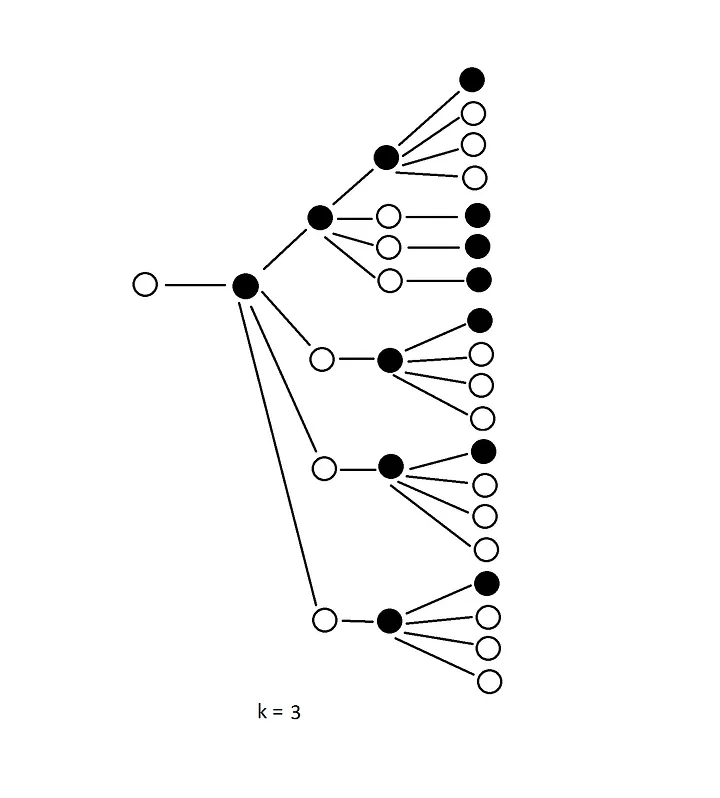

To solve this, we have to take into account both the delay and the number of offsprings.

In [ ]:
starting_pairs = 1
num_offSpring = 3

## first month
total_n1 = starting_pairs
print("total month 1: "+ str(total_n1))

## second month
total_n2 = starting_pairs
print("total month 2: "+ str(total_n2))

## third month
total_n3 = starting_pairs + num_offSpring
print("total month 3: "+ str(total_n3))

## fourth month
total_n4 = total_n3 + total_n2*num_offSpring 
print("total month 4: "+ str(total_n4))

## fifth month
total_n5 = total_n4 + total_n3*num_offSpring 
print("total month 5: "+ str(total_n5))

## Sixth month
total_n6 = total_n5 + total_n4*num_offSpring 
print("total month 6: "+ str(total_n6))

The **total number of rabbits** in each generation is equal to the number of **adults** one generation back and the number of offspring born during each mating with the number of rabbits two generations ago. We simply add this to the number of rabbits one generation ago to get our answer.

We have a solution available [here](https://medium.com/algorithms-for-life/rosalind-walkthrough-rabbits-and-recurrence-relations-4812c0c2ddb3) that allows us to check whether the code we generated is ok.

In [ ]:
## Truth
def rabbitPairs(numMonths, numOffspring):
    
    if (numMonths == 1):
        return 1
    elif (numMonths == 2):
        return numOffspring
    
    oneGen = rabbitPairs(numMonths - 1, numOffspring)
    twoGen = rabbitPairs(numMonths - 2, numOffspring)
    
    if (numMonths <= 4):
        return (oneGen + twoGen)
    
    return (oneGen + (twoGen * numOffspring))

In [ ]:
rabbitPairs(29,3)

In [ ]:
def getRabbits(starting_pairs = 1, num_offSpring = 3, month_to_check=1):

    if month_to_check<3:
        return(starting_pairs)
    
    if month_to_check==3:
        return(starting_pairs + num_offSpring)

    if month_to_check>3:
        total_n1= getRabbits(starting_pairs, num_offSpring, month_to_check-1)
        total_n2= getRabbits(starting_pairs, num_offSpring, month_to_check-2)

        total_n = total_n1 + total_n2*num_offSpring 

        return(total_n)


In [ ]:
rabbitPairs(4,3)

In [ ]:
getRabbits(starting_pairs=1, num_offSpring=3, month_to_check=5)

In [ ]:
rabbitPairs(6,3) == getRabbits(starting_pairs=1, num_offSpring=3, month_to_check=6)

Create a single file execution script from command line. See file in [`code/rabbit_count.py`](./code/rabbit_count.py)

### Mendel First Law


In this particular [exercise](https://rosalind.info/problems/iprb/), using combinations and probability, we will explore Mendel First Law of inheritance. 

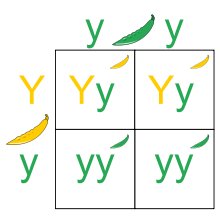

We are given a population containing k+m+n individuals where 
- k: individuals are homozygous dominant for a factor, 
- m: are heterozygous, and 
- n: are homozygous recessive.

and we need to return the probability that two randomly selected mating organisms will produce an individual possessing a dominant allele (and thus displaying the dominant phenotype)

In [ ]:
## probabilities derived from Punnet matrix
genotypes = ['AA', 'Aa', 'aa']
prob_AA = [1,1,1]
prob_Aa = [1,0.75,0.5]
prob_aa = [1,0.5,0]

import numpy as np
x = np.array([prob_AA, prob_Aa, prob_aa])
x

In [ ]:
# possible offspring with phenotype
x*4

In [ ]:
#pip install scipy

I came with a solution as mixture of some other solution, from StackOverflow forum website [here](http://stackoverflow.com/questions/25119106/rosalind-mendels-first-law-iprb)

In [ ]:
from scipy.special import comb

# k  = number of homozygous dominant organisms
k=2

# m  = number of homozygous recessive organisms
m=2

# n = number of heterozygous organisms
n=2

n_ind = k+m+n
print("Total individuals: ", n_ind)

# total population of alleles taken into account 
# 4 genotypes in each mating, and 2 individuals taken
pop_total = comb(n_ind, 2)
print("Total combinations of alleles: ", pop_total)
print("----------\n")

# dominant organisms         
## add the probability of each to produce dominant genotypes: AAxAA:1; AAxAa=1; AAxaa=1; AaxAa=3/4 Aaxaa= 2/4 and aaxaa:0/4
validCombos = 1*comb(k, 2) + 1*k*m + 1*k*n + .75*comb(m, 2) + .5*m*n + 0*comb(n, 2)

print("Dominant organisms: ", validCombos)

# probability for dominant organisms
phom = validCombos/pop_total
print("Dominant Probability: " + format(phom, ".2%"))
print("----------\n")

# Prob. dominant organisms + prob. recessive organisms equals 1
# let's check that:
rec_total = .5*n*m + .75*comb(m, 2) + .5*comb(n, 2) 
print("Recursive organisms: ", rec_total)

prec = rec_total/pop_total
print("Recursive Probability: " + format(prec, ".2%"))

print("----------\n")
if(1 - prec == phom):
    print("Prob. dominant organisms + prob. recessive organisms equals 1")
    print("Correct!")
    

Create a single file execution script from command line. See file in [`code/mend_iprb.py`](./code/mend_iprb.py)

Here there is another solution, from StackOverflow forum website [here](http://stackoverflow.com/questions/25119106/rosalind-mendels-first-law-iprb)

In [ ]:
def mendel(x, y, z):
    #calculate the probability of recessive traits only
    total = x+y+z
    twoRecess = (z/total)*((z-1)/(total-1))
    twoHetero = (y/total)*((y-1)/(total-1))
    heteroRecess = (z/total)*(y/(total-1)) + (y/total)*(z/(total-1))

    print("twoRecess:" + str(twoRecess))
    print("twoHetero:" + str(twoHetero))
    print("heteroRecess:" + str(heteroRecess))


    recessProb = twoRecess + twoHetero*1/4 + heteroRecess*1/2
    print(1-recessProb) # take the complement

mendel(2, 2, 2)

### Computing GC Content

We need to compute the GC content of a sequence and return the fasta sequence with the highest count

In [ ]:
from Bio import SeqIO

Read sequence data from file

In [ ]:
with open(os.path.join(stronghold_data_folder, 'test_GC_content.fasta')) as handle:
    for record in SeqIO.parse(handle, "fasta"):
        print(record.id)


In [ ]:
record

Use Biopython SeqUtils to calculate GC fraction

In [ ]:
from Bio.SeqUtils import gc_fraction
gc_fraction(record.seq)

Read, calculate and save

In [ ]:
from Bio.SeqUtils import gc_fraction
from Bio import SeqIO

dict_GC = {}
with open(os.path.join(stronghold_data_folder, 'test_GC_content.fasta')) as handle:
    for record in SeqIO.parse(handle, "fasta"):
        dict_GC[record.id] = [gc_fraction(record), record.seq]

In [ ]:
dict_GC

In [ ]:
dict_GC.items()


Get highest value for GC data

In [ ]:
res = max(dict_GC, key=lambda k: dict_GC[k][0])
print(res)

Save as fasta format

In [ ]:
fasta_format_string = ">%s\n%s\n" %(res, str(dict_GC[res][1]))
print(fasta_format_string)


In [ ]:
print(res + "\n" + str(dict_GC[res][0]))

Create a single file execution script from command line. See file in [`code/gc_count.py`](./code/gc_count.py)

### Translating RNA into Protein

Following the problem schedule, we will now convert RNA into protein. See [here](https://rosalind.info/problems/prot/) additional details.

In [ ]:
rna_string = "AUGGCCAUGGCGCCCAGAACUGAGAUCAAUAGUACCCGUAUUAACGGGUGA"

In [ ]:
genetic_code = '''UUU F
CUU L
AUU I
GUU V
UUC F
CUC L
AUC I
GUC V
UUA L
CUA L
AUA I
GUA V
UUG L
CUG L
AUG M
GUG V
UCU S
CCU P
ACU T
GCU A
UCC S
CCC P
ACC T
GCC A
UCA S
CCA P
ACA T
GCA A
UCG S
CCG P
ACG T
GCG A
UAU Y
CAU H
AAU N
GAU D
UAC Y
CAC H
AAC N
GAC D
UAA Stop
CAA Q
AAA K
GAA E
UAG Stop
CAG Q
AAG K
GAG E
UGU C
CGU R
AGU S
GGU G
UGC C
CGC R
AGC S
GGC G
UGA Stop
CGA R
AGA R
GGA G
UGG W
CGG R
AGG R
GGG G'''

In [ ]:

genetic_dict={}
for codon in genetic_code.split("\n"):
    codon_list = codon.split(" ")
    if codon_list[1]=="Stop":
        codon_list[1]="*"
    genetic_dict[codon_list[0]] = codon_list[1]

In [ ]:
print(genetic_dict)

In [ ]:
list_codons = [rna_string[i:i+3] for i in range(0, len(rna_string), 3)]
print(list_codons)


In [ ]:

amino_acids = [genetic_dict[cdn] for cdn in list_codons]
final_string = "".join(map(str, amino_acids))
print(final_string)

Easy and simple way using Biopython

In [ ]:
from Bio.Seq import Seq
Seq(rna_string).translate()

Create a single file execution script from command line. See file in [`code/rna2prot.py`](./code/rna2prot.py)

### Finding a motif in DNA

In [ ]:
s_seq = "GATATATGCATATACTT"
t_seq = "ATAT"

In [ ]:
#s_seq.find(t_seq)
s_seq.find(t_seq)

In [ ]:
s_seq[4:].find(t_seq)

In [ ]:
s_seq = "GATATATGCATATACTT"
t_seq = "ATAT"
hits = []
while(s_seq.find(t_seq) > 0):
    hit_pos = s_seq.index(t_seq)
    s_seq = s_seq[hit_pos+1:]
    try:
        hits.append(hits[-1]+hit_pos+1)
    except:
        hits.append(hit_pos+1)


In [ ]:
hits

In [ ]:
print(" ".join(map(str, hits)))


Create a single file execution script from command line. See file in [`code/subs_string.py`](./code/subs_string.py)

### Counting Point mutations

Calculate the hamming distance which is the number of corresponding symbols that differ in s1 and s2

In [ ]:
s1="GAGCCTACTAACGGGAT"
s2="CATCGTAATGACGGCCT"

In [ ]:
len(s1)

In [ ]:
hm=0
for i in range(len(s1)):
    print("Index:" + str(i))
    print("s1: "+ s1[i] +"; s2: " + s2[i])
    if s1[i] == s2[i]:
        print("\tMatch!")
    else:
        print("\tError!")
        hm +=1
    print("")

print("Hamming distance: " + str(hm))
        

In [ ]:
hm = sum(a != b for a, b in zip(s1, s2))
print(hm)

Create a single file execution script from command line. See file in [`code/hm_dist.py`](./code/hm_dist.py)

## Level 3: Following exercises

Several new problems are open once you solved the previous ones. Such as:
- [Consensus and Profile](https://rosalind.info/problems/cons/)
- [Finding a Shared Motif](https://rosalind.info/problems/lcsm/)  
- [Enumerating Gene Orders](https://rosalind.info/problems/perm/)
- [Finding a Protein Motif](https://rosalind.info/problems/mprt/)
- [Inferring mRNA from Protein](https://rosalind.info/problems/mrna/)
- [Open Reading Frames](https://rosalind.info/problems/orf/)
- [Calculating Protein Mass](https://rosalind.info/problems/prtm/)
- [RNA Splicing](https://rosalind.info/problems/splc/)
- [Mortal Fibonnacci problems](https://rosalind.info/problems/fibd/)
- ...

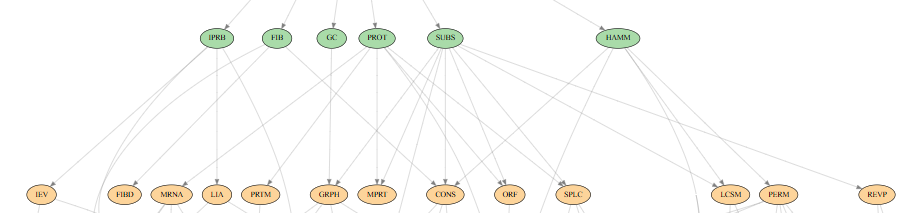

### Consensus and profile

In [this](https://rosalind.info/problems/cons/) exercise, given a set of fasta sequences, create a consensus string and profile matrix for the collection. 

Note: If several possible consensus strings exist, then you may return any one of them.

First of all, read fasta sequences using Biopython

In [ ]:
from Bio import SeqIO
import os

dict_seq = {}
len_seq = {}
with open(os.path.join(stronghold_data_folder, 'cons_multiple_fasta.fasta')) as handle:
    for record in SeqIO.parse(handle, "fasta"):
        ## save sequence & length
        dict_seq[record.id] = str(record.seq)
        len_seq[record.id] = len(record.seq)

Check if length is the same for all sequences

In [ ]:
## get length and check
from numpy import unique
if all(len_seq.values()):
    print("All sequences have the same length")
    val_len = unique(list(len_seq.values()))[0]
    print(val_len)
else:
    print("Differences in sequence length")
        



Now, we will traverse the alignment, get the columnn and the total count. We will use zip of all the possible sequences.

In [ ]:
cons_seq = ""
profile = []
for i in range(val_len):
    dict_nuc = {"A":0, "C":0, "G":0, "T":0}

    ## count for each column of the alignment 
    ## the amount of each nucleotide
    for [a] in zip(dict_seq.values()):
        dict_nuc[a[i]] += 1

    ## get the profile for each alignment column
    profile.append(list(dict_nuc.values()))
    #print(dict_nuc)

    ## Get most common
    cons_seq += max(dict_nuc, key=lambda k: dict_nuc[k])
   
    

In [ ]:
print(profile)

In [ ]:
print(cons_seq)

Convert into numpy array and transpose: nucleotides as rows and columns for each position

In [ ]:
import numpy as np
profile_np = np.array(profile).transpose()
print(profile_np)

In [ ]:
## as an example
np.array2string(profile_np[0]).replace("[", "").replace("]", "").split()

Print the profile of the alingment

In [ ]:
nucs = ["A", "C", "G", "T"]
for i in range(len(nucs)):
    list_num = np.array2string(profile_np[i]).replace("[", "").replace("]", "").split()
    print(nucs[i] + ": " + " ".join(list_num))

Expected output:

In [ ]:
print(cons_seq)
##
nucs = ["A", "C", "G", "T"]
for i in range(len(nucs)):
    list_num = np.array2string(profile_np[i]).replace("[", "").replace("]", "").split()
    print(nucs[i] + ": " + " ".join(list_num))


Create a single file execution script from command line. See file in [`code/cons.py`](./code/cons.py)

### Finding a shared motif

Now, we will try to identify a shared motif among sequences. See details [here](https://rosalind.info/problems/lcsm/). 

Given a collection of several sequences, produce the longest common substring of the collection. 

Note: If multiple solutions exist, you may return any single solution.

#### Solution 1

In [ ]:
os.listdir(stronghold_data_folder)

Read sequences from fasta file

In [ ]:
from Bio import SeqIO
import os

dict_seq = {}
len_seq = {}
with open(os.path.join(stronghold_data_folder, 'lcsm_multiple_fasta.fasta')) as handle:
    for record in SeqIO.parse(handle, "fasta"):
        ## save sequence & length
        dict_seq[record.id] = str(record.seq)
        len_seq[record.id] = len(record.seq)


Get sequences to start with and others

In [ ]:
## get shortest sequence
shortest_seq_id = min(len_seq, key=lambda k: len_seq[k])
shortest_seq = dict_seq[shortest_seq_id]
##
print(shortest_seq_id)
print(shortest_seq)
        

In [ ]:
seqs2test =  list(dict_seq.keys() - [shortest_seq_id])

In [ ]:
print(shortest_seq)
print(shortest_seq[:-1])
print(shortest_seq)


In [ ]:
seqs2test[0].find(shortest_seq[:-1])

Generate all substrings using list comprehension


In [ ]:
# Generate all substrings using list comprehension
substrings_all = [shortest_seq[i:j] for i in range(len(shortest_seq)) for j in range(i+1, len(shortest_seq)+1)]

## return only longer or equal to 2
substrings = [s for s in substrings_all if len(s) > 1]

## sort from longest-shortest
substrings = sorted(substrings, key=len)[::-1]

# Print the result
print(substrings)

In [ ]:
## get sequences to test
list_of_seqs2test=[]
for seqs in seqs2test:
    list_of_seqs2test.append(dict_seq[seqs])



Get all matches for all sequences


In [ ]:
## get all matches for all sequences
sub_substrings = {}

for s2test in seqs2test:
    list_tmp = []
    for s in substrings:
        #print("sub")
        #print(s)
        if (dict_seq[s2test].find(s)>0):
            list_tmp.append(s)

    sub_substrings[s2test]=list_tmp

    #print("s2test: ")
    #print(list_tmp)

In [ ]:
import pprint
pprint.pprint(sub_substrings)

Print nicely

In [ ]:
from collections import Counter
counter = Counter(item for values in sub_substrings.values() for item in set(values))
print(counter)
common = [item for item, count in counter.items() if count >= 2]
common_longest = sorted(common, key=len)[::-1]
print(common_longest)

This first solution works for a naive set of sequences but when applied to a large datasets, it collapses. Some changes should be made to increase performance. 

#### Solution 2

Read file again using Biopython

In [ ]:
from Bio import SeqIO
import os

dict_seq = {}
len_seq = {}
with open(os.path.join(stronghold_data_folder, 'rosalind_lcsm.txt')) as handle:
#with open(os.path.join(stronghold_data_folder, 'lcsm_multiple_fasta.fasta')) as handle:
    for record in SeqIO.parse(handle, "fasta"):
        ## save sequence & length
        dict_seq[record.id] = str(record.seq)
        len_seq[record.id] = len(record.seq)


In [ ]:
## get shortest sequence
shortest_seq_id = min(len_seq, key=lambda k: len_seq[k])
shortest_seq = dict_seq[shortest_seq_id]


In [ ]:
shortest_seq

In [ ]:
## get remaining sequences to index
seqs2test =  list(dict_seq.keys() - [shortest_seq_id])
print(seqs2test[1:10])

Now, instead obtaining all substrings and then search, do it all in one step and quickly skip entries that do not meet criteria

In [ ]:
from collections import defaultdict
dict_motif = defaultdict(int)

min_lentgh_motif = 50

## get remaining sequences to index
seqs2test =  list(dict_seq.keys() - [shortest_seq_id])

## apply parallel threads
for i in range(len(shortest_seq)):
    for j in range(i+1, len(shortest_seq)+1):
        substrings_str = shortest_seq[i:j]
        ## debug
        #print(substrings_str)
        #print(len(substrings_str))
        if (len(substrings_str) < min_lentgh_motif):
            #print("Very small")
            continue
        
        ## debug
        #print("i - j:" + str(i) + " - " + str(j))
        #print(substrings_str)
               
        ## get all matches for all sequences
        for s2test in seqs2test:
            #print(s2test)
            if (dict_seq[s2test].find(substrings_str)>0):
                dict_motif[substrings_str] += 1


In [ ]:
import json
print(json.dumps(dict_motif, indent=4))        # Pretty print JSON


Pretty print sequences

In [ ]:
import os
stronghold_data_folder = os.path.abspath("./data")

with open(os.path.join(stronghold_data_folder, "res_tmp.txt"), "w") as f:
    json.dump(dict_motif, f, indent=4)

In [ ]:
dict_motif_all = {k: v for k, v in dict_motif.items() if v==99}

res = max(dict_motif_all.keys(), key=lambda k: len(k))
print(res)

print(len(res))


Create a single file execution script from command line. See file in [`code/lscm.py`](./code/lscm.py)

### Enumerating gene order

Here, we have an [exercise](https://rosalind.info/problems/perm/) that requires to obtain the permutations of a number

In [ ]:
int_given=6
list_num=list(range(1,int_given+1))
print(list_num)

In [ ]:

from itertools import permutations

count_perm = 0
perm_str = ""
perm = permutations(list_num)

for i in perm:
    count_perm +=1
    print(i)

    perm_str += " ".join(map(str, i))+"\n"

In [ ]:
with open(os.path.join(stronghold_data_folder, "res_perm.txt"), "w") as f:
    f.write(str(count_perm)+"\n")
    f.write(perm_str)

In [ ]:
print(count_perm)
print(perm_str)

Create a single file execution script from command line. See file in [`code/perm.py`](./code/perm.py)

### Finding a Protein Motif

In the following [link](https://rosalind.info/problems/mprt/), we can find details in the exercise for Finding a Protein Motif. We need to connect to uniprot, download data and find a specific domain coordinates

In the EMBL-EBI, there is a nice [webinar](https://www.ebi.ac.uk/training/events/programmatic-access-uniprot-using-python/) and code available on Python Notebook on colab [here](https://colab.research.google.com/drive/1i9UtVqa4m9WQ4ZVJkbGdwWbto_W7zmP_?usp=sharing). I got some ideas and I would develop others myself

To allow for the presence of its varying forms, a protein motif is represented by a shorthand as follows: [XY] means "either X or Y" and {X} means "any amino acid except X." 

For example, the N-glycosylation motif is written as N{P}[ST]{P}.

In [ ]:
import requests, sys, json

# Documentation: https://www.uniprot.org/help/api
WEBSITE_API = "https://rest.uniprot.org/"

# Documentation: https://www.ebi.ac.uk/proteins/api/doc/
PROTEINS_API = "https://www.ebi.ac.uk/proteins/api"

# Helper function to download data
def get_url(url, **kwargs):
  response = requests.get(url, **kwargs);

  if not response.ok:
    print(response.text)
    response.raise_for_status()
    sys.exit()

  return response


# all of the entry as an example
r = get_url(f"{WEBSITE_API}/uniprotkb/O60260")
# only the catalytic activity comments
# r = get_url(f"{WEBSITE_API}/uniprotkb/O60260?fields=cc_catalytic_activity")
print(json.dumps(r.json(), indent=2))

In [ ]:
## Rosalind example

# all of the entry as an example
r = get_url(f"{WEBSITE_API}/uniprotkb/B5ZC00")
print(json.dumps(r.json(), indent=2))

In [ ]:
r = get_url(f"{WEBSITE_API}/uniprotkb/B5ZC00?fields=sequence")
print(json.dumps(r.json(), indent=2))
data = r.json()

In [ ]:
## get the sequence
seq_str = data['sequence']['value']

Create a simple function to retrieve sequence from Uniprot ID

In [ ]:

import requests, sys, json

# Helper function to download data
def get_url(url, **kwargs):
  response = requests.get(url, **kwargs);

  if not response.ok:
    print(response.text)
    response.raise_for_status()
    sys.exit()

  return response

def get_uniprot_seq(uniprot_id):

  uniprot_id = uniprot_id.split("_")[0]

  # Documentation: https://www.uniprot.org/help/api
  WEBSITE_API = "https://rest.uniprot.org/"

  # all of the entry as an example
  r = get_url(f"{WEBSITE_API}/uniprotkb/%s?fields=sequence" %uniprot_id)
  data = r.json()
  ## get the sequence
  seq_str = data['sequence']['value']

  return(seq_str)



In [ ]:
get_uniprot_seq("B5ZC00")

Now, once we have the sequence, we need to search the motif of interest. N-glycosylation motif is written as N{P}[ST]{P} 

In [ ]:
## search the motif of interest
import re
re_str = "N[^P][ST][^P]"

list_hits = re.findall("N[^P][ST][^P]", seq_str)
## ['NFSD', 'NSSN', 'NWTE', 'NLSK', 'NISA']

## get hits index
string_hits_list = [seq_str.index(k)+1 for k in list_hits]

#string_hits_dict = {k: seq_str.index(k)+1 for k in list_hits}
motif_str_hits = " ".join(map(str, string_hits_list))
print(motif_str_hits)


In [ ]:
def get_motif_hits(re_str, seq_str):
    ## search the motif of interest
    import re
    list_hits = re.findall(re_str, seq_str)
    
    ## get hits index as a dictionary
    string_hits_dict = {k: seq_str.index(k)+1 for k in list_hits}
    return(string_hits_dict)

In [ ]:
get_motif_hits(re_str=re_str, seq_str=get_uniprot_seq("B5ZC00"))


In [ ]:
get_motif_hits(re_str=re_str, seq_str=get_uniprot_seq("P20840_SAG1_YEAST"))

## {"url":"http://rest.uniprot.org/uniprotkb/P07204_TRBM_HUMAN","messages":["The 'accession' value has invalid format. It should be a valid UniProtKB accession"]}


In [ ]:
get_motif_hits(re_str=re_str, seq_str=get_uniprot_seq("P20840"))

In [ ]:
get_motif_hits(re_str=re_str, seq_str=get_uniprot_seq("P07204"))

I should debug to raise an error when some hits are erroneous

In [ ]:
get_motif_hits(re_str=re_str, seq_str=get_uniprot_seq("P0C5G9"))

In [ ]:
get_motif_hits(re_str=re_str, seq_str=get_uniprot_seq("Q66GC7"))

In [ ]:
get_motif_hits(re_str=re_str, seq_str=get_uniprot_seq("P10761_ZP3_MOUSE"))

In [ ]:
test_seq = get_uniprot_seq("P10761_ZP3_MOUSE")

In [ ]:
len(test_seq)

Allow overlapping hits

In [ ]:
import regex as re
re_str = "N[^P][ST][^P]"
list_hits = re.findall(re_str, test_seq, overlapped=True)

print(list_hits)

for k in list_hits:
    print(k)


Create a single file execution script from command line. See file in [`code/mprt.py`](./code/mprt.py)

### Locating Restriction Sites

In the following exercise, see details [here](https://rosalind.info/problems/revp/), work on identifying palindrome sequences.

A DNA string is a reverse palindrome if it is equal to its reverse complement. For instance, GCATGC is a reverse palindrome because its reverse complement is GCATGC. 

In this exercise, given a DNA string of length at most 1 kbp in FASTA format. Return the position and length of every reverse palindrome in the string having length between 4 and 12. 

In [ ]:
from Bio.Seq import Seq

In [ ]:
example_seq_1 = Seq("TCAATGCATGCGGGTCTATATGCAT")
example_seq_1

In [ ]:
example_seq_2 = str(Seq(example_seq_1).complement())

In [ ]:
print(example_seq_1)
print("|"*len(example_seq_1))
print(example_seq_2)

Now, for the following DNA strand, search for palindromic sequences between 4-12 bp

Take into account that several palindromic sequences might appear at the same position with different length, do not go further than the expected sequence length

In [ ]:
debug_flag = 1
palindromic_hits = {}
seq2check = example_seq_1
min_len_pal=4
max_len_pal=12
for i in range(len(seq2check)):
    for j in range(min_len_pal, max_len_pal+1):
        end_bp = i+j

        ## skip if longer than sequence
        if (end_bp > len(seq2check)):
            break

        sub1 = str(seq2check[i:end_bp])
        sub2 = str(Seq(sub1).reverse_complement())

        ## testing debug
        if debug_flag == 2:
            print("Position: " + str(i))
            print("Subset: " + str(i) + ":" + str(end_bp))
            print(sub1)

        ## check if sequences match    
        if (sub1==sub2):
            ## keep track of results
            palindromic_hits["pos_" + str(i) + "_" + str(j)] = [i+1, end_bp+1, j, sub1, sub2]

            if debug_flag > 0:
                print("#######################")
                print("Match!")
                print("Subset: " + str(i) + ":" + str(end_bp))

                print(sub1)
                print("|"*len(sub1))
                print(Seq(sub1).complement())
                print("#######################")
                print()


In [ ]:
palindromic_hits

In [ ]:
print("\n".join([str(v[0]) + " " + str(v[2]) for k,v in palindromic_hits.items()]))

A nice sequence that lets you test inplace multiple panlindromic sequences

In [ ]:
"TTTAAATTTAAA"

Create a single file execution script from command line. See file in [`code/revp.py`](./code/revp.py)

### RNA Splicing

Eukaryotic genes are discontinous, they contain intron sequences that must be removed from genomic sequences.

See details of the exercise [here](https://rosalind.info/problems/splc/). As stated, after identifying the exons and introns of an RNA string, we only need to delete the introns and concatenate the exons to form a new string ready for translation.

In this problem, given a DNA string and a collection of substrings, acting as introns, we need to return a protein string resulting from transcribing and translating the exons

In [ ]:
from Bio import SeqIO

sequences_record =[]
with open("data/test_splc.fasta") as handle:
    for record in SeqIO.parse(handle, "fasta"):
        ## save sequence & length
        sequences_record.append(record)

In [ ]:
## genomic dna string
str(sequences_record[0].seq)

In [ ]:
## intron 1
sequences_record[1]

In [ ]:
## intron is within DNAseq
str(sequences_record[0].seq).index(str(sequences_record[1].seq))

We will have to remove the exon and add the remaining seqs.

In [ ]:
genomic_dna = str(sequences_record[0].seq)
intron1 = str(sequences_record[1].seq)

if genomic_dna.index(intron1):
    start_bp = genomic_dna.index(intron1)
    end_bp = start_bp + len(intron1)

    print(genomic_dna[0:start_bp] + genomic_dna[end_bp:])

In [ ]:
## How many introns are there
len(sequences_record)

In [ ]:
genomic_dna = str(sequences_record[0].seq)
start_bp=0
final_str=genomic_dna

for i in range(1, len(sequences_record)):
    intron_seq = str(sequences_record[i].seq)
    print(intron_seq)
    if final_str.index(intron_seq):
        index_intron = final_str.index(intron_seq)
        end_bp = index_intron + len(intron_seq)

        print("Coordinates: ")
        print("First:  start - end: " + str(start_bp) + " - " + str(index_intron))
        print("Second: start - end: " + str(end_bp) + " - End" )
        print(final_str[start_bp:index_intron] + final_str[end_bp:])

        final_str = final_str[start_bp:index_intron] + final_str[end_bp:]

prot_seq = Seq(final_str).translate()
print(prot_seq.replace("*",""))


Create a single file execution script from command line. See file in [`code/splc.py`](./code/splc.py)

### Overlap Graphs

A graph whose nodes have all been labeled can be represented by an adjacency list, in which each row of the list contains the two node labels corresponding to a unique edge.

In this [exercise](https://rosalind.info/problems/grph/), for a collection of strings and a positive integer k, the overlap graph for the strings is a directed graph Ok, in which each string is represented by a node, and string s is connected to string t with a directed edge when there is a length k suffix of s that matches a length k prefix of t, as long as s≠t; we demand s≠t to prevent directed loops in the overlap graph (although directed cycles may be present).



In [ ]:
from Bio import SeqIO

sequences_record =[]
with open("data/test_grph.txt") as handle:
    for record in SeqIO.parse(handle, "fasta"):
        ## save sequence & length
        sequences_record.append(record)

In [ ]:
sequences_record

In [ ]:
k=3
## all sequence
print(sequences_record[1].seq)

## first 3 bp
print(sequences_record[1].seq[0:3])

## last 3 bp
print(sequences_record[1].seq[-k:])


In [ ]:
k=3
adjacency_list = []
for i in sequences_record:
    for j in sequences_record:
        if (i.id != j.id):
            print("i: " + i.id + " ---- " + "j: " + j.id)

            ## check suffixes match prefixes of length k: Directed graph
            if (i.seq[-k:] == j.seq[0:k]):
                adjacency_list.append([i.id, j.id])

In [ ]:
pprint.pprint(adjacency_list)

Now, we need to remove entries that are already present previously. 

As an example.

    Rosalind_0498 Rosalind_2391
    Rosalind_2391 Rosalind_0498 

Any of these two entries should be discarded


In [ ]:
from collections import defaultdict
adjacency_list = defaultdict(int)

k=3
for i in sequences_record:
    for j in sequences_record:
        if (i.id != j.id):
            print("i: " + i.id + " ---- " + "j: " + j.id)

            ## check suffixes match prefixes of length k: Directed graph
            if (i.seq[-k:] == j.seq[0:k]):
                list_edges = [i.id, j.id]
                list_edges_str = "---".join(list_edges)
                adjacency_list[list_edges_str] +=1

In [ ]:
adjacency_list

In [ ]:
print("\n".join([str(k.split("---")[0]) + " " + str(k.split("---")[1]) for k in adjacency_list.keys()]))

By allowing a directed graph, we should allow that these two entries are returned twice:

    Rosalind_1234 AAATAAA 
    Rosalind_1235 AAAGAAA

Create a single file execution script from command line. See file in [`code/grph.py`](./code/grph.py)

### Protein Mass

In this [exercise](https://rosalind.info/problems/prtm/), given a monoisotopic mass table (a table listing the mass of each possible amino acid residue, where the value of the mass used is the monoisotopic mass of each residue) return the total weight of the protein.



In [ ]:
## read as dictionary the table
file2read = "./data/monoisotopic_mass_table.txt"
d={}
with open(file2read) as f:
    for line in f:
        line = line.strip()
        (key, val) = line.split()
        d[key] = float(val)

print(d)

In [ ]:
## read proteic sequence
with open("./data/test_prtm.txt") as f:
  prot_string = f.read()

In [ ]:
print(sum([d[i] for i in prot_string]))

Maybe raise an error to discard any non valid character

Create a single file execution script from command line. See file in [`code/prtm.py`](./code/prtm.py)

### Inferring mRNA from Protein

In [ ]:
from Bio.Data.CodonTable import unambiguous_dna_by_id

# Load the standard genetic code (ID 1)
table = unambiguous_dna_by_id[1]
print(table)

# Invert forward_table (codon -> aa) 
# to map amino acid -> list of codons
aa_to_codons = {}
for codon, aa in table.forward_table.items():
    aa_to_codons.setdefault(aa, []).append(codon)

## add stop codons
aa_to_codons['*'] = table.stop_codons

## add start codons aa_to_codons['^'] = table.start_codons

# Example: Get all codons for Alanine ('A')
print(aa_to_codons.get("A"))

In [ ]:
import pprint
pprint.pprint(aa_to_codons)

In [ ]:
print(aa_to_codons['*'])

In [ ]:
## original protein sequence
prot_seq = "MSSIPTCKDPYKPYNWVHVDMWEYTFMGCPFAKKWRHEYQRTATYFGLQKMATSNTKSLRITHARVLIKMQHHGRRRFNKDKNWMKHWHGKAANLGMEILFIEKWTCHQQRCITTWAHISDCKFACPTNRYLHHGKHCSPHQHYYTKLSDKSALHDQVVVTLCRAVFVQHWEKMSCKIHILHMVYQFYIYKDWCTAQHGHTLPVMGEEARDMAKFAVAQMWPMLVCYRLELDFKSVALYKEFAALLRRVNLCVKDVSLDWVYNHIRASYVASTCVVFWDRTRLIVQIHQKWVVYYCKHTYDKDWEKTGWPDWTHLKLWEYKCVRTRQFPTQQHSSKHPDVVSVCWWNSRGKEHWTNHGSQTPSKRIFFNQQAPMIIDPVQEDFSCFVRQWIVMPNDGSMKPPEICKHMPVDGASPRRFTEVHKLRLEWRVGTQSEDHEHRCRMHRYSSTRIPPCFCTALMLITDDQGDGILMGSSRYNPHLAVYDYIPRPDYIESCVGVKYHVRKHHFRCSTSNVWMAMSWVMKKPKSVAISYCHAKVGSRMAQIIGGYRGRFCLEAYVDGFESRSIPERNEKHHERLMMKGLCGNDRQHGGVMFENGLVLPFMMSDWFEPSSRTQIGTTGINDWLPPTWRVDFEVRNMRCVIIGRRGWFGSMFSGRIQAGHCSGTKMTHLVISFCCTKITVVIIFKLMVWEMNNTCEGILKWCNVTFKDGEQFSCRRHIWLPSHDRAELYMELFHYWYCRHPMVRWRNIWQMKDTKGIMAEACAWSAYMDWNVMSATYNPSMLNYVQTGVLWRPRYGAIADWCYPSVYPYHHYQNMTFGTGITWFMTVWKDYMVADGYHRHDGGPHVQQDQSYFVSDLCADYIVMWMDFEIVYYGRLQRHDWILRNPRDHTYAYVEQHWVRCREALAKPPNFGPCYLQCGS"

## add starting coding and add stop codon
#prot_seq_r = prot_seq.replace("M", "^", count=1) + '*'

## add stop codon
prot_seq_r = prot_seq + '*'

## get possibilities
listOfCodons = []
for i in prot_seq_r:
    codons = aa_to_codons.get(i)
    print(codons)
    listOfCodons.append(codons)

In [ ]:
listOfCodons

We can get to see all the combinations...

In [ ]:
import itertools
from collections import Counter

counter_p = 0
for l in (itertools.product(*listOfCodons)):
    counter_p +=1

But it might not be necessary

In [ ]:
total_count = 1
for i in listOfCodons:
    total_count *= len(i)

In [ ]:
total_count % 1000000

Create a single file execution script from command line. See file in [`code/mrna.py`](./code/mrna.py)